In [1]:
print("hello world")

hello world


In [3]:
import numpy as np
import pandas as pd
from parallel_pandas import ParallelPandas
ParallelPandas.initialize(n_cpu=12, split_factor=1)

from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource
output_notebook()

Loading BokehJS ...

In [ ]:
data = pd.read_csv("./../data/995,500_rows_stemming_words.csv", index_col=0)
data = data["content"]
data = data.p_apply(lambda s: s.replace("< num >", "<num>"))
data = data.p_apply(lambda s: s.replace("< date >", "<date>"))
data = data.p_apply(lambda s: s.replace("< email >", "<email>"))
data = data.p_apply(lambda s: s.replace("< url >", "<url>"))
data = data.p_apply(lambda s: s.split(" "))

<LAMBDA> DONE: 100%|██████████| 5000/5000 [00:07<00:00, 631.72it/s] 


0       [plus, one, articl, googl, plus, (, thank, ali...
1       [cost, best, senat, bank, committe, jp, morgan...
2       [man, awoken, <num>, -year, coma, commit, suic...
3       [julia, geist, ask, draw, pictur, comput, scie...
4       [–, <num>, compil, studi, vaccin, danger, (, a...
                              ...                        
4995    [unless, understand, realiti, manifest, ,, des...
4996    [tor, tor, encrypt, anonymis, network, make, h...
4997    [h/t, wendi, ann, :, ﻿jakarta, ,, indonesia, (...
4998    [readi, ,, qe, <num>, ,, long-term, effect, re...
4999    [<num>, time, wore, massiv, headdress, oscar, ...
Name: content, Length: 5000, dtype: object

In [4]:
flatten = data.explode()

In [5]:
freqs = flatten.value_counts()

In [6]:
toplot = freqs[0:1000]
toplot

content
,               124272
.               102293
<num>            39089
’                26055
“                16210
                 ...  
canada             311
relationship       311
forward            311
owner              311
various            310
Name: count, Length: 1000, dtype: int64

In [7]:
bins = np.arange(0, len(toplot)-1)
hist, edges = np.histogram(toplot.to_numpy(), bins=bins)

In [15]:
source = ColumnDataSource(data={
    'x': np.arange(0, toplot.shape[0]),
    'token': toplot.index.tolist(),
    'y': toplot.values.tolist()
})

In [ ]:
p = figure(height=400, 
           width=600,
           title="Bar Chart from Pandas Series",
           x_range=(0, toplot.shape[0]), 
           x_axis_type="linear",
           y_axis_type="log",
           tools="pan,wheel_zoom,box_zoom,save,reset,help,hover",
           tooltips=[("index", "@token"), ("count", "@y")],
           )
p.hover.mode = "vline"
p.step(x='x', y='y', source=source, line_width=2)
p.line(x='x', y='y', source=source, alpha=0) # For hover tool

GlyphRenderer(id='p1126', ...)

In [17]:
show(p)

<Axes: xlabel='content'>

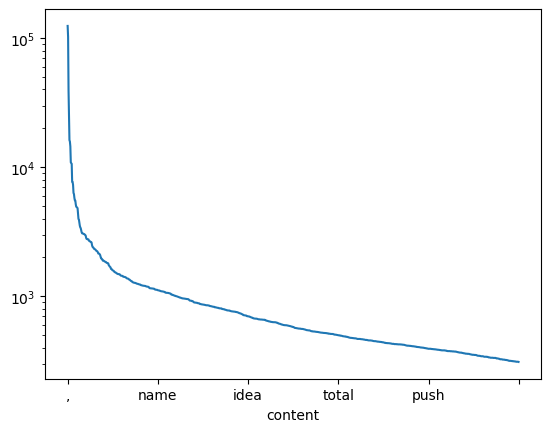

In [11]:
toplot.plot(kind='line',logy=True)